## Imports

In [1]:
import os
import math
import random
import shutil
from pathlib import Path

import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

## DATASET 

In [2]:
def split_dataset(img_dir, mask_dir, output_dir, split=(0.8, 0.1, 0.1), seed=42):
    random.seed(seed)
    img_dir    = Path(img_dir)
    mask_dir   = Path(mask_dir)
    output_dir = Path(output_dir)

    filenames = sorted([f.stem for f in img_dir.glob("*.jpg")])
    random.shuffle(filenames)

    n       = len(filenames)
    n_train = int(n * split[0])
    n_val   = int(n * split[1])

    splits = {
        "train": filenames[:n_train],
        "val"  : filenames[n_train:n_train + n_val],
        "test" : filenames[n_train + n_val:]
    }

    for split_name, files in splits.items():
        for subfolder in ["images", "masks"]:
            (output_dir / split_name / subfolder).mkdir(parents=True, exist_ok=True)
        for fname in files:
            shutil.copy(img_dir  / f"{fname}.jpg", output_dir / split_name / "images" / f"{fname}.jpg")
            shutil.copy(mask_dir / f"{fname}.jpg", output_dir / split_name / "masks"  / f"{fname}.jpg")
        print(f"{split_name}: {len(files)} samples")


In [3]:
img_dir    = "/kaggle/input/kvasirseg/Kvasir-SEG/Kvasir-SEG/images"
mask_dir   = "/kaggle/input/kvasirseg/Kvasir-SEG/Kvasir-SEG/masks"
output_dir = "/kaggle/working/"

In [4]:
split_dataset(img_dir=img_dir, mask_dir=mask_dir, output_dir=output_dir)

train: 800 samples
val: 100 samples
test: 100 samples


In [6]:
class MedSegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.imgs      = sorted(os.listdir(img_dir))
        self.masks     = sorted(os.listdir(mask_dir))
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img  = np.array(Image.open(os.path.join(self.img_dir,  self.imgs[idx])).convert("RGB"))
        mask = np.array(Image.open(os.path.join(self.mask_dir, self.masks[idx])).convert("L"))
        if self.transform:
            out  = self.transform(image=img, mask=mask)
            img  = out["image"]
            mask = out["mask"]
        mask = (mask > 0.5).float().unsqueeze(0)
        return img, mask

## Transforms

In [7]:
train_tf = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

In [8]:
train_ds = MedSegDataset("/kaggle/working/train/images", "/kaggle/working/train/masks", transform=train_tf)
val_ds   = MedSegDataset("/kaggle/working/val/images",   "/kaggle/working/val/masks",   transform=val_tf)
test_ds  = MedSegDataset("/kaggle/working/test/images",  "/kaggle/working/test/masks",  transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
# NOTE: batch_size reduced from 16 → 8 because the Transformer bottleneck
# uses more GPU memory than the NonLocalBlock did.

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 800 | Val: 100 | Test: 100


# Model Architecture
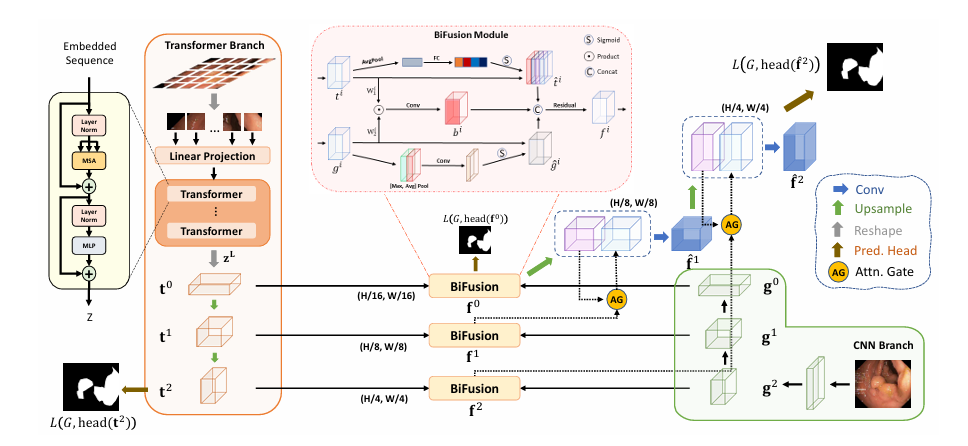

## PART A — CNN Branch (ResNet34 pretrained)

In [9]:
class CNNBranch(nn.Module):
    """
    ResNet34 encoder extracting features at 3 scales.
      g0 : (B,  64, H/4,  W/4 )
      g1 : (B, 128, H/8,  W/8 )
      g2 : (B, 256, H/16, W/16)
    """
    def __init__(self, pretrained=True):
        super().__init__()
        resnet = timm.create_model('resnet34', pretrained=pretrained,
                                   features_only=True, out_indices=(1, 2, 3))
        self.encoder = resnet

    def forward(self, x):
        feats = self.encoder(x)
        g0 = feats[0]   # (B,  64, H/4,  W/4)
        g1 = feats[1]   # (B, 128, H/8,  W/8)
        g2 = feats[2]   # (B, 256, H/16, W/16)
        return g0, g1, g2

## PART B — Transformer Branch (DeiT-S pretrained)

In [10]:
class TransformerBranch(nn.Module):
    """
    DeiT-S encoder producing multi-scale spatial features.
    z^L token sequence is reshaped into 3 spatial scales via
    Linear Projection + bilinear interpolation.

      t0 : (B, embed_dim, H/16, W/16)   deepest
      t1 : (B, embed_dim, H/8,  W/8 )
      t2 : (B, embed_dim, H/4,  W/4 )   shallowest
    """
    def __init__(self, pretrained=True, embed_dim=384):
        super().__init__()
        self.deit = timm.create_model('deit_small_patch16_224',
                                      pretrained=pretrained,
                                      num_classes=0)
        self.embed_dim = embed_dim

        # One linear projection per scale
        self.proj0 = nn.Linear(embed_dim, embed_dim)
        self.proj1 = nn.Linear(embed_dim, embed_dim)
        self.proj2 = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, C, H, W = x.shape

        # DeiT-S expects 224×224
        x_resized = F.interpolate(x, size=(224, 224),
                                  mode='bilinear', align_corners=False)

        # Extract tokens: (B, 197, 384) → remove cls → (B, 196, 384)
        tokens = self.deit.forward_features(x_resized)
        tokens = tokens[:, 1:, :]    # (B, 196, 384)
        ph = pw = 14                 # 14×14 patch grid for 224×224 input

        # Scale 0 — deepest (H/16 × W/16)
        t0 = self.proj0(tokens).transpose(1, 2).reshape(B, self.embed_dim, ph, pw)
        t0 = F.interpolate(t0, size=(H // 16, W // 16),
                           mode='bilinear', align_corners=False)

        # Scale 1 — mid (H/8 × W/8)
        t1 = self.proj1(tokens).transpose(1, 2).reshape(B, self.embed_dim, ph, pw)
        t1 = F.interpolate(t1, size=(H // 8, W // 8),
                           mode='bilinear', align_corners=False)

        # Scale 2 — shallowest (H/4 × W/4)
        t2 = self.proj2(tokens).transpose(1, 2).reshape(B, self.embed_dim, ph, pw)
        t2 = F.interpolate(t2, size=(H // 4, W // 4),
                           mode='bilinear', align_corners=False)

        return t0, t1, t2


## PART C — Channel Alignment (1×1 Conv)

In [11]:
class ChannelAlign(nn.Module):
    """1×1 Conv to bring CNN and Transformer features to same channel dim."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


## PART D — BiFusion Module

In [12]:
class BiFusion(nn.Module):
    """
    BiFusion Module — paper core contribution.

    Channel Attention on Transformer features  (what channels matter?)
    Spatial Attention on CNN features          (which locations matter?)
    Hadamard product fusion                    (both must agree)
    + Residual connection
    """
    def __init__(self, in_ch):
        super().__init__()

        # Channel Attention (on Transformer features t)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_ch, in_ch // 4, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(in_ch // 4, in_ch, bias=False),
            nn.Sigmoid()
        )

        # Spatial Attention (on CNN features g)
        self.spatial_conv = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False),
            nn.Sigmoid()
        )

        # Fusion conv — refines channel-weighted transformer features
        self.fusion_conv = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True)
        )

        # Residual projection
        self.residual = nn.Sequential(
            nn.Conv2d(in_ch * 2, in_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, t, g):
        """
        t : Transformer features (B, C, H, W)
        g : CNN features         (B, C, H, W)
        returns: fused f         (B, C, H, W)
        """
        B, C, H, W = t.shape

        # Channel attention on t
        w = self.avg_pool(t).view(B, C)
        w = self.fc(w).view(B, C, 1, 1)
        t_weighted = t * w

        # Spatial attention on g
        g_max = g.max(dim=1, keepdim=True)[0]
        g_avg = g.mean(dim=1, keepdim=True)
        s = self.spatial_conv(torch.cat([g_max, g_avg], dim=1))
        g_weighted = g * s

        # Hadamard product + residual
        b = self.fusion_conv(t_weighted)
        fused    = b * g_weighted
        residual = self.residual(torch.cat([t, g], dim=1))

        return fused + residual

## PART E — Attention Gate

In [13]:
class AttentionGate(nn.Module):
    """
    Attention Gate from Attention U-Net.
    Filters skip features using deeper decoder context as guide.
    Suppresses irrelevant background, keeps relevant regions.
    """
    def __init__(self, x_ch, g_ch, mid_ch):
        super().__init__()
        self.W_x = nn.Sequential(
            nn.Conv2d(x_ch, mid_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid_ch)
        )
        self.W_g = nn.Sequential(
            nn.Conv2d(g_ch, mid_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid_ch)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(mid_ch, 1, kernel_size=1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, g):
        if g.shape[2:] != x.shape[2:]:
            g = F.interpolate(g, size=x.shape[2:],
                              mode='bilinear', align_corners=False)
        alpha = self.psi(self.relu(self.W_x(x) + self.W_g(g)))
        return x * alpha

## PART F — Decoder Block

In [14]:
class DecoderBlock(nn.Module):
    """Upsample → Attention Gate on skip → Concat → Conv×2"""
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.ag  = AttentionGate(x_ch=skip_ch, g_ch=in_ch, mid_ch=skip_ch // 2)
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch + skip_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )

    def forward(self, x, skip):
        x    = self.up(x)
        skip = self.ag(skip, g=x)
        return self.conv(torch.cat([x, skip], dim=1))



## PART G — Prediction Head

In [15]:
class PredHead(nn.Module):
    """Conv 1×1 → upsample to input size. Used at all 3 supervision points."""
    def __init__(self, in_ch, num_classes=1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, num_classes, kernel_size=1)

    def forward(self, x, target_size):
        return F.interpolate(self.conv(x), size=target_size,
                             mode='bilinear', align_corners=False)

## PART H — TransFuse Full Model

In [16]:

class TransFuse(nn.Module):
    """
    Two parallel branches:
      CNN Branch  : ResNet34 pretrained → g0, g1, g2
      Trans Branch: DeiT-S  pretrained → t0, t1, t2

    BiFusion fuses at 3 scales → f0, f1, f2
    Decoder with Attention Gates → fhat1 → fhat2

    3 supervision points (deep supervision):
      head(t2)    ← Transformer branch auxiliary loss
      head(f0)    ← BiFusion deepest scale auxiliary loss
      head(fhat2) ← Final output (main loss)
    """
    def __init__(self, num_classes=1, fusion_ch=256, pretrained=True):
        super().__init__()

        # Branches
        self.cnn_branch   = CNNBranch(pretrained=pretrained)
        self.trans_branch = TransformerBranch(pretrained=pretrained, embed_dim=384)

        # Channel alignment — CNN: 64/128/256 → fusion_ch, Trans: 384 → fusion_ch
        self.align_g0 = ChannelAlign(64,  fusion_ch)
        self.align_g1 = ChannelAlign(128, fusion_ch)
        self.align_g2 = ChannelAlign(256, fusion_ch)
        self.align_t0 = ChannelAlign(384, fusion_ch)
        self.align_t1 = ChannelAlign(384, fusion_ch)
        self.align_t2 = ChannelAlign(384, fusion_ch)

        # BiFusion at 3 scales
        self.bifusion0 = BiFusion(fusion_ch)
        self.bifusion1 = BiFusion(fusion_ch)
        self.bifusion2 = BiFusion(fusion_ch)

        # Decoder
        self.dec1 = DecoderBlock(in_ch=fusion_ch, skip_ch=fusion_ch, out_ch=128)
        self.dec2 = DecoderBlock(in_ch=128,        skip_ch=fusion_ch, out_ch=64)

        # 3 Prediction Heads for deep supervision
        self.head_t     = PredHead(fusion_ch, num_classes)  # on t2
        self.head_f0    = PredHead(fusion_ch, num_classes)  # on f0
        self.head_final = PredHead(64,        num_classes)  # on fhat2 (main)

    def forward(self, x):
        B, C, H, W = x.shape
        target_size = (H, W)

        # CNN Branch
        g0, g1, g2 = self.cnn_branch(x)

        # Transformer Branch
        t0, t1, t2 = self.trans_branch(x)

        # Channel Alignment
        g0 = self.align_g0(g0)   # (B, 256, H/4,  W/4)
        g1 = self.align_g1(g1)   # (B, 256, H/8,  W/8)
        g2 = self.align_g2(g2)   # (B, 256, H/16, W/16)
        t0 = self.align_t0(t0)   # (B, 256, H/16, W/16)
        t1 = self.align_t1(t1)   # (B, 256, H/8,  W/8)
        t2 = self.align_t2(t2)   # (B, 256, H/4,  W/4)

        # BiFusion at 3 scales
        f0 = self.bifusion0(t0, g2)   # (B, 256, H/16, W/16) deepest
        f1 = self.bifusion1(t1, g1)   # (B, 256, H/8,  W/8)
        f2 = self.bifusion2(t2, g0)   # (B, 256, H/4,  W/4)  shallowest

        # Decoder
        fhat1 = self.dec1(f0, f1)     # (B, 128, H/8,  W/8)
        fhat2 = self.dec2(fhat1, f2)  # (B,  64, H/4,  W/4)

        # 3 Prediction Heads
        mask_t     = self.head_t(t2,     target_size)
        mask_f0    = self.head_f0(f0,    target_size)
        mask_final = self.head_final(fhat2, target_size)

        if self.training:
            return mask_final, mask_f0, mask_t
        else:
            return mask_final

##  LOSS & METRICS 

In [17]:
def weighted_iou_loss(pred, target):
    """Weighted IoU loss — paper's primary loss component."""
    pred  = torch.sigmoid(pred)
    inter = (pred * target).sum(dim=(2, 3))
    union = (pred + target).sum(dim=(2, 3))
    return (1 - (inter + 1) / (union - inter + 1)).mean()

def bce_loss(pred, target):
    return F.binary_cross_entropy_with_logits(pred, target)

class TransFuseLoss(nn.Module):
    """
    TransFuse paper loss = Weighted IoU + BCE
    Applied at all 3 supervision points with different weights.
    """
    def forward(self, preds, target):
        # preds is (mask_final, mask_f0, mask_t) during training
        # preds is mask_final during inference
        if isinstance(preds, tuple):
            mask_final, mask_f0, mask_t = preds
            loss_final = weighted_iou_loss(mask_final, target) + bce_loss(mask_final, target)
            loss_f0    = weighted_iou_loss(mask_f0,    target) + bce_loss(mask_f0,    target)
            loss_t     = weighted_iou_loss(mask_t,     target) + bce_loss(mask_t,     target)
            return loss_final + 0.3 * loss_f0 + 0.4 * loss_t
        else:
            return weighted_iou_loss(preds, target) + bce_loss(preds, target)


def dice_score(pred, target, threshold=0.5, smooth=1e-6):
    # pred may be tuple during training — use final output only
    if isinstance(pred, tuple):
        pred = pred[0]
    pred         = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum(dim=(2, 3))
    union        = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    return ((2 * intersection + smooth) / (union + smooth)).mean().item()


def iou_score(pred, target, threshold=0.5, smooth=1e-6):
    if isinstance(pred, tuple):
        pred = pred[0]
    pred         = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum(dim=(2, 3))
    union        = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) - intersection
    return ((intersection + smooth) / (union + smooth)).mean().item()



## TRAINING LOOP 

In [18]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    total_loss, total_dice, total_iou = 0, 0, 0

    for imgs, masks in tqdm(loader, desc="Train", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()

        if scaler is not None:
            with torch.cuda.amp.autocast():
                preds = model(imgs)
                loss  = criterion(preds, masks)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            preds = model(imgs)
            loss  = criterion(preds, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(preds, masks)
        total_iou  += iou_score(preds, masks)

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_dice, total_iou = 0, 0, 0

    for imgs, masks in tqdm(loader, desc="Val  ", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        loss  = criterion(preds, masks)
        total_loss += loss.item()
        total_dice += dice_score(preds, masks)
        total_iou  += iou_score(preds, masks)

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n

## PLOT 

In [19]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"],   label="Val")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(epochs, history["train_dice"], label="Train")
    axes[1].plot(epochs, history["val_dice"],   label="Val")
    axes[1].set_title("Dice Score"); axes[1].set_xlabel("Epoch"); axes[1].legend()

    axes[2].plot(epochs, history["train_iou"], label="Train")
    axes[2].plot(epochs, history["val_iou"],   label="Val")
    axes[2].set_title("IoU Score"); axes[2].set_xlabel("Epoch"); axes[2].legend()

    plt.tight_layout()
    plt.savefig("training_history_transunet.png", dpi=150)
    plt.show()

## TRAIN FUNCTION

In [20]:
def train(model, train_loader, val_loader, epochs=50, lr=1e-4, device="cuda"):
    criterion = TransFuseLoss()

    # Differential LR: pretrained branches get smaller LR
    optimizer = torch.optim.AdamW([
        {"params": model.cnn_branch.parameters(),   "lr": lr * 0.1},
        {"params": model.trans_branch.parameters(), "lr": lr * 0.1},
        {"params": model.align_g0.parameters(),     "lr": lr},
        {"params": model.align_g1.parameters(),     "lr": lr},
        {"params": model.align_g2.parameters(),     "lr": lr},
        {"params": model.align_t0.parameters(),     "lr": lr},
        {"params": model.align_t1.parameters(),     "lr": lr},
        {"params": model.align_t2.parameters(),     "lr": lr},
        {"params": model.bifusion0.parameters(),    "lr": lr},
        {"params": model.bifusion1.parameters(),    "lr": lr},
        {"params": model.bifusion2.parameters(),    "lr": lr},
        {"params": model.dec1.parameters(),         "lr": lr},
        {"params": model.dec2.parameters(),         "lr": lr},
        {"params": model.head_t.parameters(),       "lr": lr},
        {"params": model.head_f0.parameters(),      "lr": lr},
        {"params": model.head_final.parameters(),   "lr": lr},
    ], weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

    scaler = torch.cuda.amp.GradScaler() if device == "cuda" else None

    history = {
        "train_loss": [], "val_loss": [],
        "train_dice": [], "val_dice": [],
        "train_iou" : [], "val_iou" : []
    }

    best_dice = 0.0

    for epoch in range(1, epochs + 1):
        train_loss, train_dice, train_iou = train_one_epoch(
            model, train_loader, optimizer, criterion, device, scaler
        )
        val_loss, val_dice, val_iou = evaluate(model, val_loader, criterion, device)

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_dice"].append(train_dice)
        history["val_dice"].append(val_dice)
        history["train_iou"].append(train_iou)
        history["val_iou"].append(val_iou)

        print(f"Epoch [{epoch:02d}/{epochs}]  "
              f"Loss: {train_loss:.4f}/{val_loss:.4f}  "
              f"Dice: {train_dice:.4f}/{val_dice:.4f}  "
              f"IoU: {train_iou:.4f}/{val_iou:.4f}")

        if val_dice > best_dice:
            best_dice = val_dice
            torch.save(model.state_dict(), "best_transfuse.pth")
            print(f"  ✓ Best model saved (Dice: {best_dice:.4f})")

    plot_history(history)
    return history



In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = TransFuse(
    num_classes = 1,
    fusion_ch   = 256,
    pretrained  = True,
).to(device)

# Shape check
dummy = torch.randn(2, 3, 256, 256).to(device)
model.eval()
out = model(dummy)
assert out.shape == (2, 1, 256, 256)
print(f"✓ {out.shape} | params: {sum(p.numel() for p in model.parameters()):,}")

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

✓ torch.Size([2, 1, 256, 256]) | params: 34,069,165


/tmp/ipykernel_55/3088614472.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device == "cuda" else None
Train:   0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_55/339820042.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [01/50]  Loss: 1.8823/0.9393  Dice: 0.6843/0.7838  IoU: 0.5621/0.6768
  ✓ Best model saved (Dice: 0.7838)


Epoch [02/50]  Loss: 1.4369/0.8745  Dice: 0.8003/0.8291  IoU: 0.6974/0.7364
  ✓ Best model saved (Dice: 0.8291)


Epoch [03/50]  Loss: 1.2684/0.7954  Dice: 0.8311/0.8441  IoU: 0.7377/0.7538
  ✓ Best model saved (Dice: 0.8441)


Epoch [04/50]  Loss: 1.1547/0.7420  Dice: 0.8516/0.8529  IoU: 0.7666/0.7736
  ✓ Best model saved (Dice: 0.8529)


...

Epoch [46/50]  Loss: 0.2950/0.4066  Dice: 0.9534/0.8794  IoU: 0.9134/0.8165


Epoch [47/50]  Loss: 0.2880/0.4073  Dice: 0.9553/0.8792  IoU: 0.9163/0.8167


Epoch [48/50]  Loss: 0.2855/0.4062  Dice: 0.9542/0.8799  IoU: 0.9153/0.8170


Epoch [49/50]  Loss: 0.2904/0.4078  Dice: 0.9547/0.8796  IoU: 0.9159/0.8165


Epoch [50/50]  Loss: 0.2881/0.4102  Dice: 0.9545/0.8785  IoU: 0.9154/0.8154


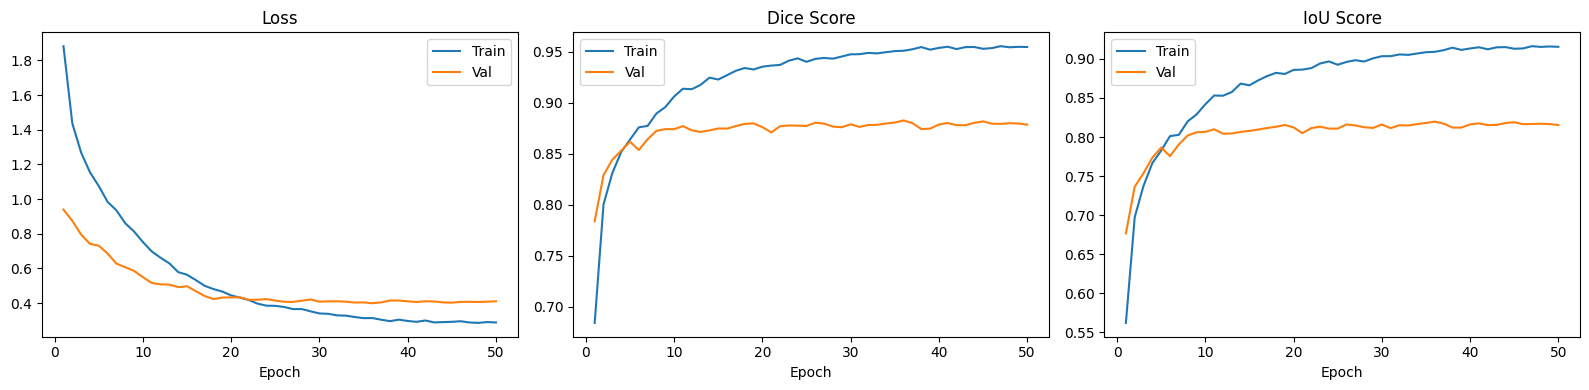

In [22]:
history = train(model, train_loader, val_loader, epochs=50, lr=1e-4, device=device)

## INFERENCE & VISUALIZATION

In [27]:
infer_tf = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])


@torch.no_grad()
def predict(model, image_path, device, threshold=0.5):
    img         = np.array(Image.open(image_path).convert("RGB"))
    original    = img.copy()
    transformed = infer_tf(image=img)["image"].unsqueeze(0).to(device)
    pred        = torch.sigmoid(model(transformed))
    pred_mask   = (pred.squeeze().cpu().numpy() > threshold).astype(np.uint8)
    return original, pred_mask


def visualize(model, dataset, device, num_samples=6, threshold=0.5):
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))
    fig.suptitle("TransFuse — Image | Ground Truth | Prediction",
                 fontsize=16, fontweight="bold", y=1.01)   # ← push above subplots

    col_titles = ["Image", "Ground Truth", "Prediction"]

    for row, idx in enumerate(indices):
        img_tensor, mask_tensor = dataset[idx]

        with torch.no_grad():
            pred      = torch.sigmoid(model(img_tensor.unsqueeze(0).to(device)))
            pred_mask = (pred.squeeze().cpu().numpy() > threshold).astype(np.uint8)

        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img  = img_tensor.permute(1, 2, 0).numpy()
        img  = (img * std + mean).clip(0, 1)
        gt   = mask_tensor.squeeze().numpy()

        images = [img, gt, pred_mask]
        cmaps  = [None, "gray", "gray"]

        for col in range(3):
            axes[row, col].imshow(images[col], cmap=cmaps[col])
            axes[row, col].axis("off")
            # Only show column titles on the first row
            if row == 0:
                axes[row, col].set_title(col_titles[col], fontsize=12, pad=8)

    plt.tight_layout()
    plt.savefig("inference_transfuse.png", dpi=150, bbox_inches="tight")
    plt.show()

def visualize_overlay(model, dataset, device, num_samples=6, threshold=0.5):
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples * 4))
    fig.suptitle("TransFuse — Prediction Overlay",
                 fontsize=16, fontweight="bold", y=1.01)   # ← push above subplots

    col_titles = ["Original", "Prediction Overlay"]

    for row, idx in enumerate(indices):
        img_tensor, _ = dataset[idx]

        with torch.no_grad():
            pred      = torch.sigmoid(model(img_tensor.unsqueeze(0).to(device)))
            pred_mask = (pred.squeeze().cpu().numpy() > threshold).astype(np.float32)

        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img  = img_tensor.permute(1, 2, 0).numpy()
        img  = (img * std + mean).clip(0, 1)

        overlay             = img.copy()
        overlay[pred_mask == 1] = [1.0, 0.0, 0.0]
        blended             = (0.6 * img + 0.4 * overlay).clip(0, 1)

        for col, image in enumerate([img, blended]):
            axes[row, col].imshow(image)
            axes[row, col].axis("off")
            # Only show column titles on the first row
            if row == 0:
                axes[row, col].set_title(col_titles[col], fontsize=12, pad=8)

    plt.tight_layout()
    plt.savefig("overlay_transfuse.png", dpi=150, bbox_inches="tight")
    plt.show()

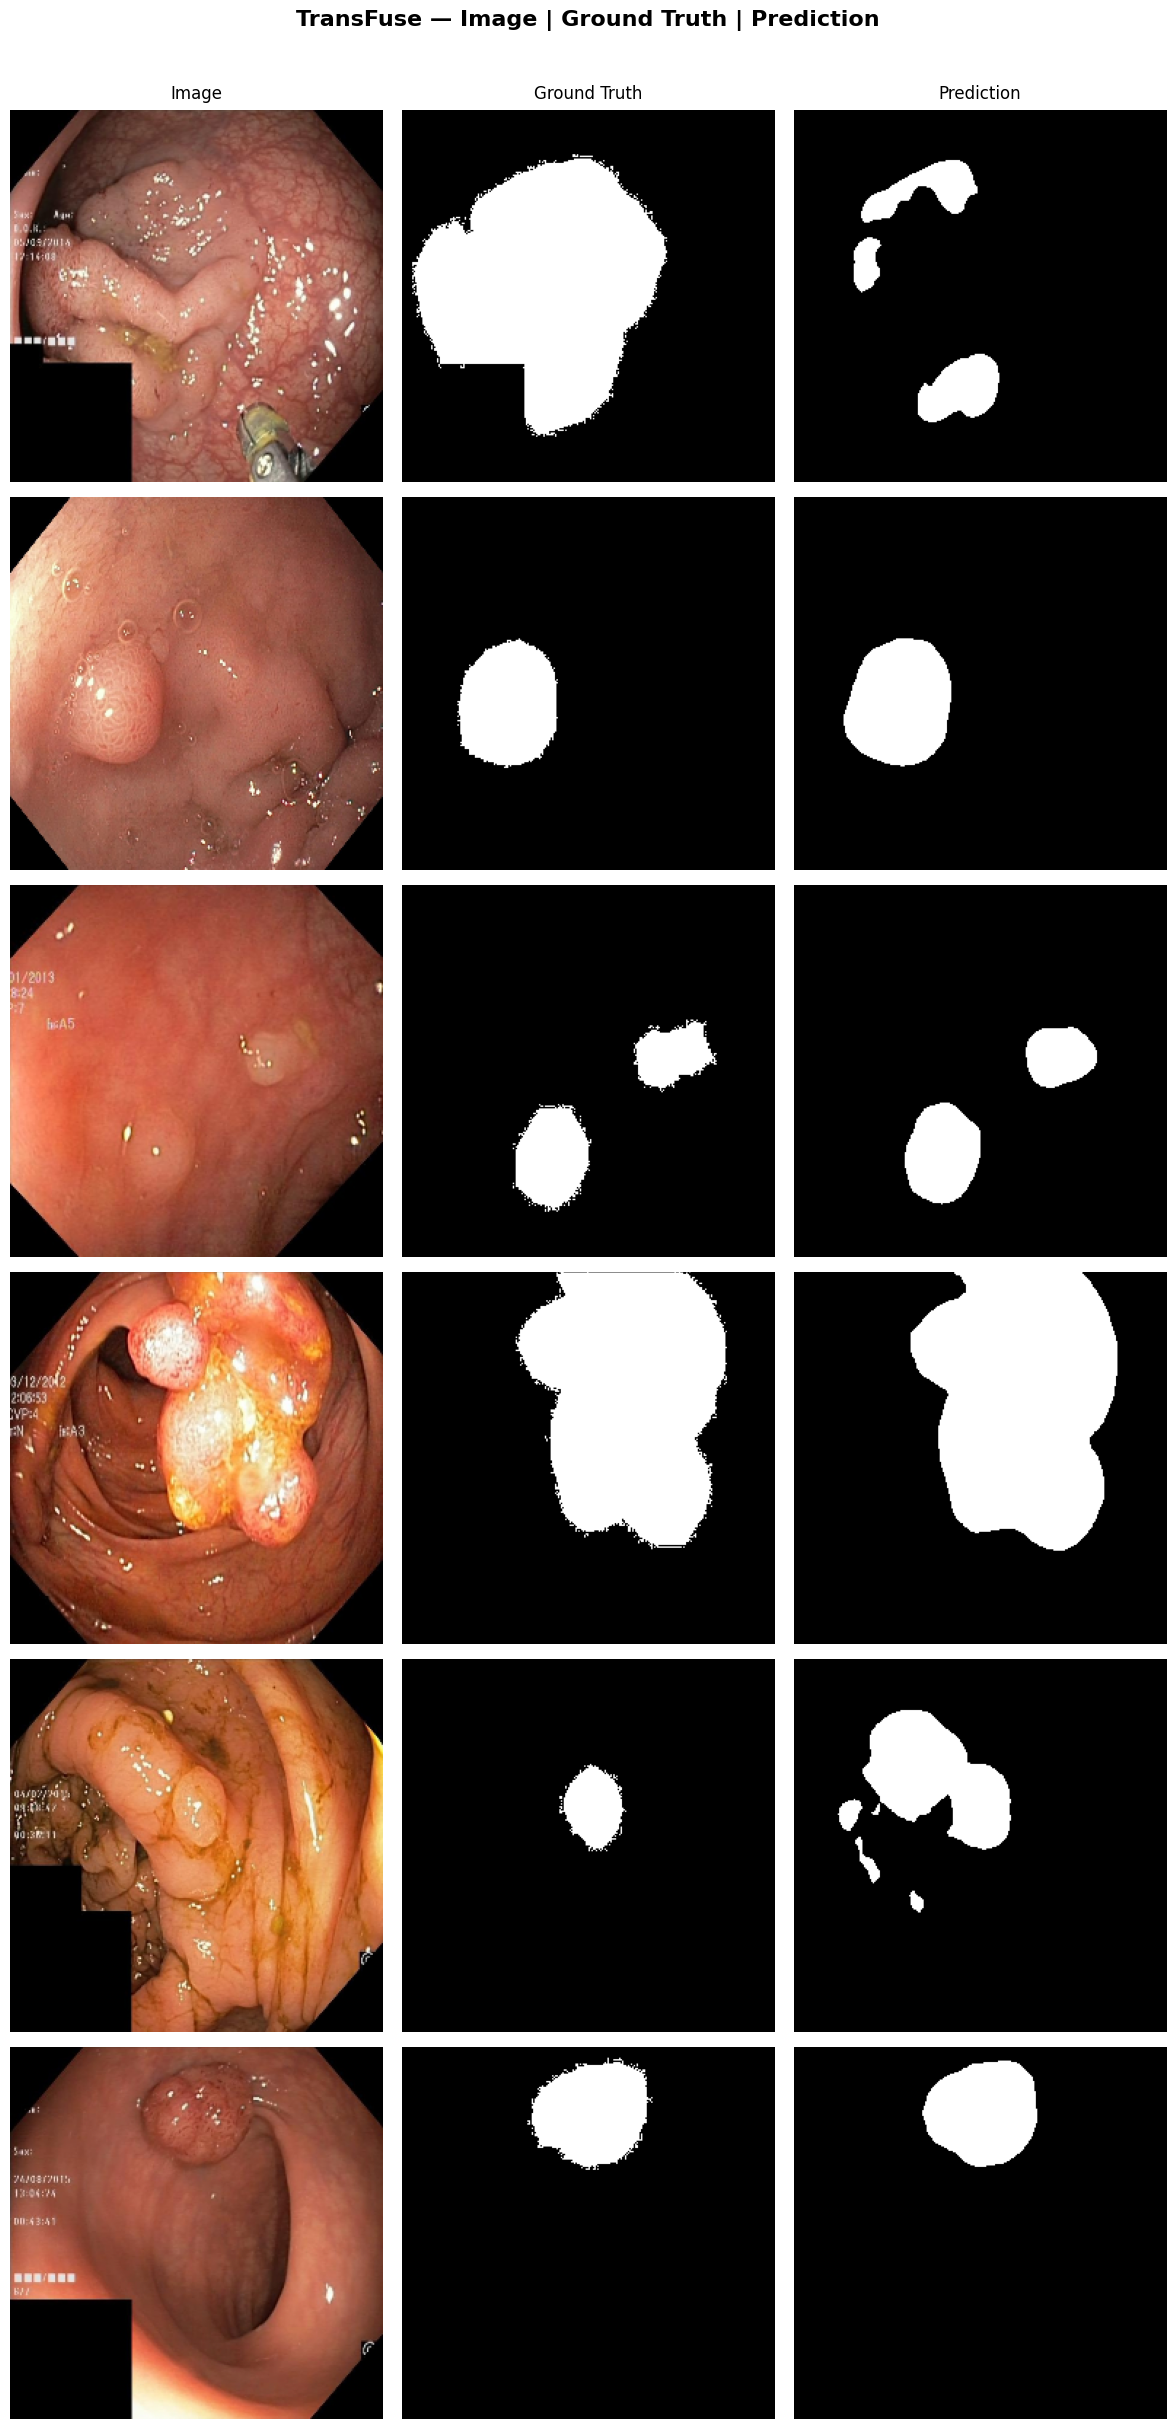

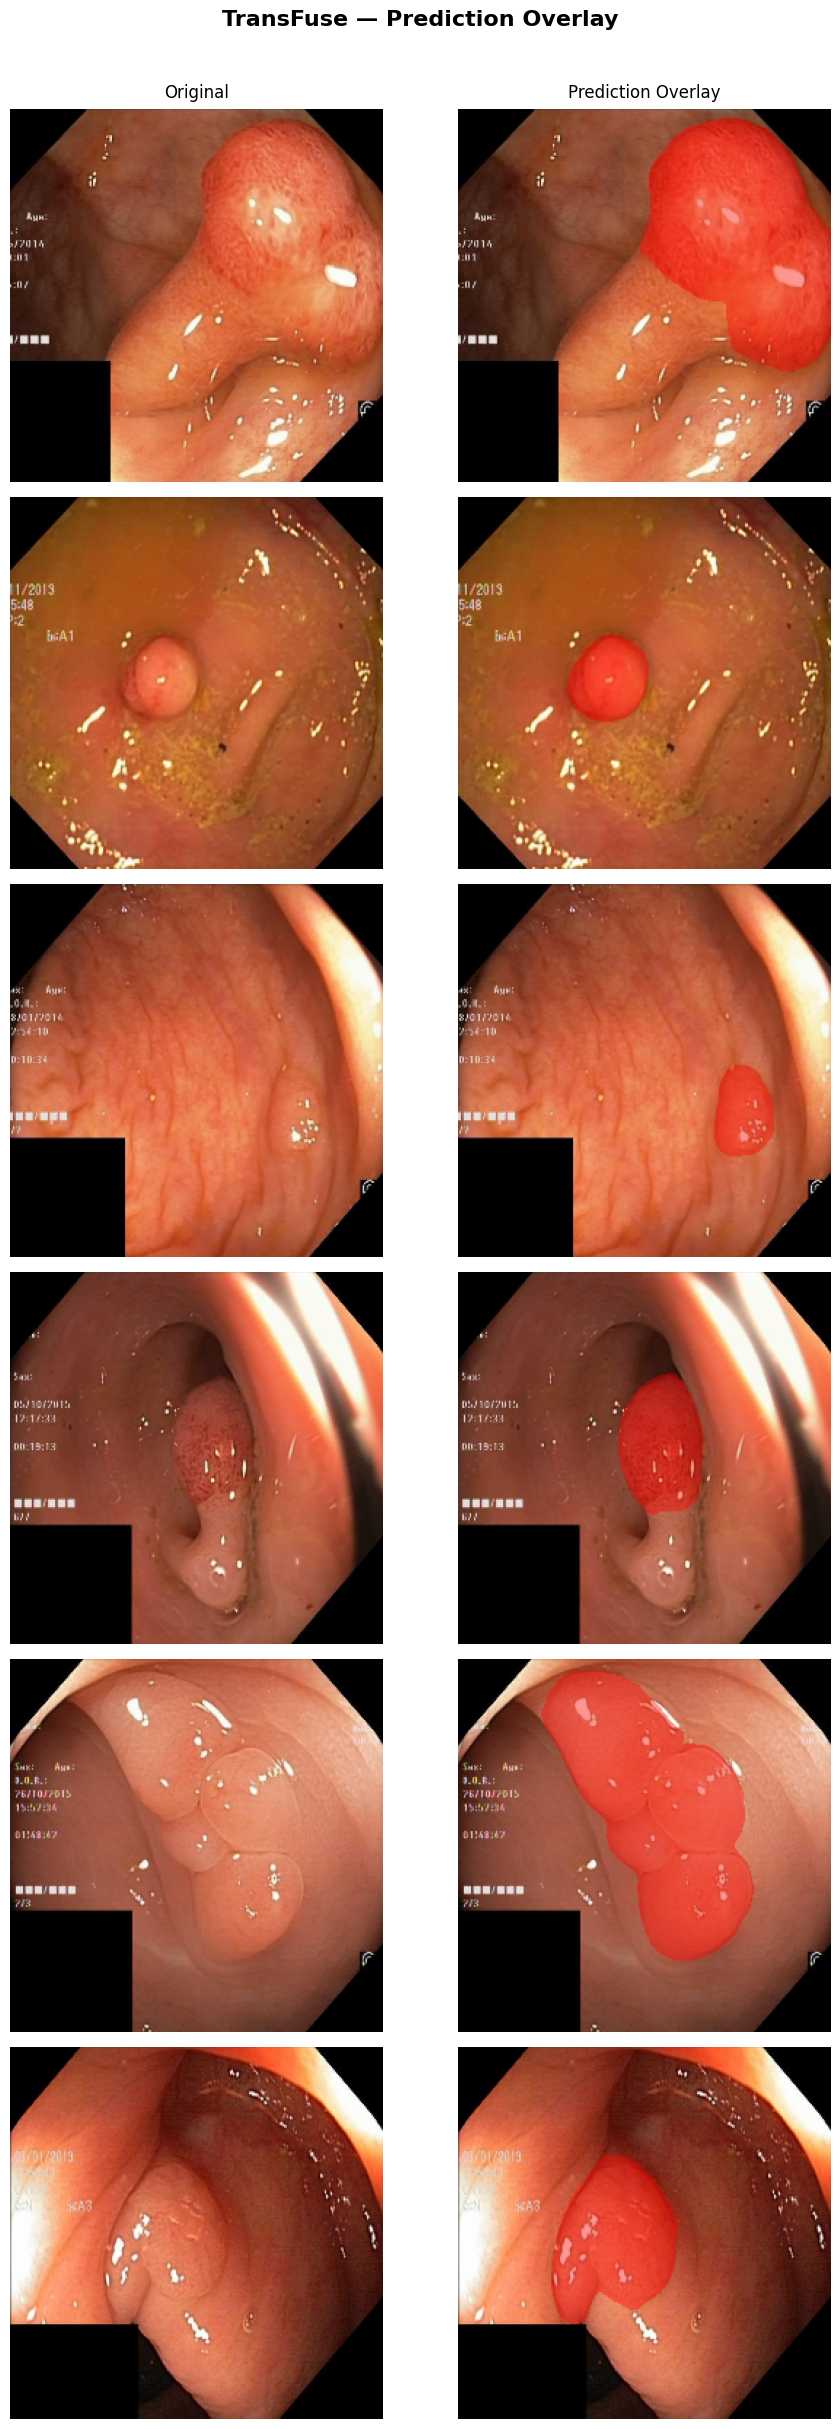

In [28]:
# Load best model and visualize
device = "cuda" if torch.cuda.is_available() else "cpu"
model = TransFuse(num_classes=1, fusion_ch=256, pretrained=False).to(device)
model.load_state_dict(torch.load("best_transfuse.pth", map_location=device))
model.eval()

visualize(model, test_ds, device, num_samples=6)
visualize_overlay(model, test_ds, device, num_samples=6)